In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df = pd.read_csv('train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
cols_needed = ['GrLivArea', 'TotalBsmtSF', 'BedroomAbvGr',
               'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
               'SalePrice']
df = df[cols_needed].copy()

In [ ]:
print(df.isnull().sum())

GrLivArea       0
TotalBsmtSF     0
BedroomAbvGr    0
FullBath        0
HalfBath        0
BsmtFullBath    0
BsmtHalfBath    0
SalePrice       0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['SquareFootage'] = df['GrLivArea'] + df['TotalBsmtSF']
df['Bedrooms'] = df['BedroomAbvGr']
df['Bathrooms'] = (df['FullBath'] + 0.5 * df['HalfBath']
                    + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

df = df[['SquareFootage', 'Bedrooms', 'Bathrooms', 'SalePrice']]
df.describe()

,SquareFootage,Bedrooms,Bathrooms,SalePrice
count,1457.000000,1457.000000,1457.000000,1457.000000
mean,2573.930679,2.866850,2.211393,181018.150995
std,823.894858,0.816287,0.785510,79493.410948
min,334.000000,0.000000,1.000000,34900.000000
25%,2015.000000,2.000000,2.000000,130000.000000
50%,2480.000000,3.000000,2.000000,163000.000000
75%,3010.000000,3.000000,2.500000,214000.000000
max,11752.000000,8.000000,6.000000,755000.000000


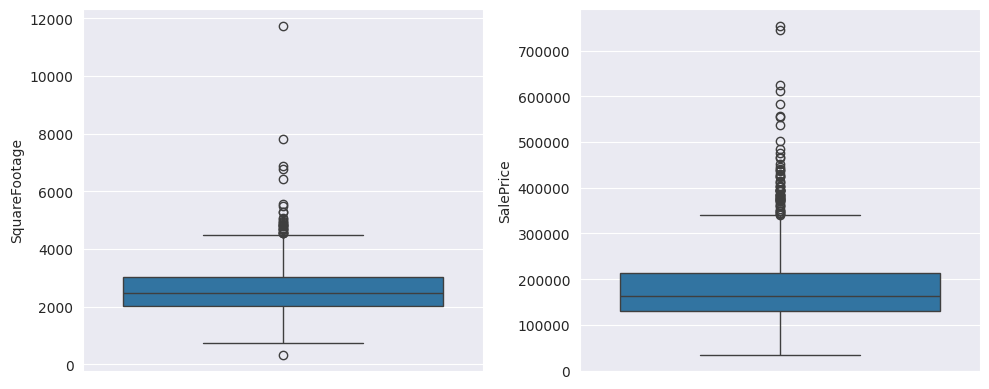

Removed 81 outlier rows (1457 -> 1376)


In [ ]:
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['SquareFootage'], ax=axes[0])
sns.boxplot(y=df['SalePrice'], ax=axes[1])
plt.tight_layout()
plt.show()

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

before = df.shape[0]
df = remove_outliers_iqr(df, 'SquareFootage')
df = remove_outliers_iqr(df, 'SalePrice')
after = df.shape[0]
print(f"Removed {before - after} outlier rows ({before} -> {after})")

In [ ]:
X = df[['SquareFootage', 'Bedrooms', 'Bathrooms']]
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled = scaler.transform(X_test)          # reuse same scaler on test

print(X_train_scaled.shape, X_test_scaled.shape)

(1100, 3) (276, 3)


In [ ]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Coefficients:", dict(zip(X.columns, model.coef_)))
print("Intercept:", model.intercept_)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"Linear Regression -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

Coefficients: {'SquareFootage': np.float64(230051.92803485526), 'Bedrooms': np.float64(-72215.54531270712), 'Bathrooms': np.float64(114676.97127450845)}
Intercept: 70060.24850372918
Linear Regression -> MAE: 25545.00, RMSE: 35484.56, R2: 0.6104


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True)[:5],
    'Predicted': y_pred[:5]
})
print(comparison)

   Actual      Predicted
0  158000  136482.394489
1  244000  308277.609558
2  153000  165393.219272
3  194700  191568.999545
4  173000  173427.361284


In [ ]:
lasso_model = Lasso(alpha=1.0, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
print("Lasso MAE:", mean_absolute_error(y_test, lasso_pred))

ridge_model = Ridge(alpha=1.0, max_iter=10000)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))

Lasso MAE: 25542.864511790423
Ridge MAE: 25382.31893984773


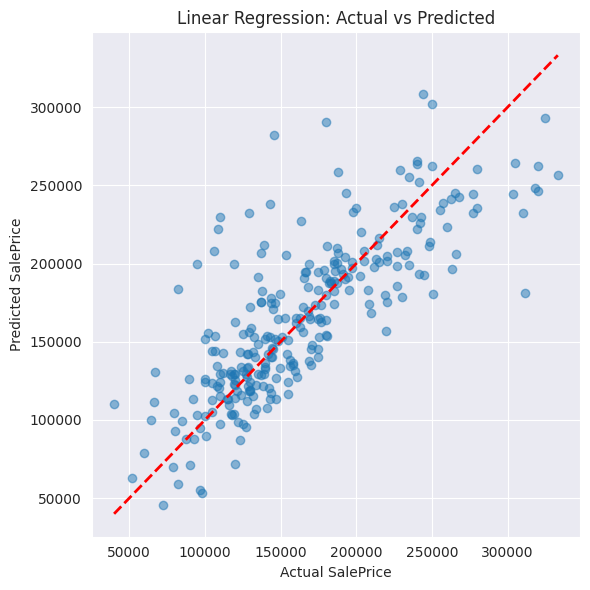

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
          'r--', lw=2)
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()